rapide check de ce qui est possible avec plotting de ilearn et l'api de niivue

In [10]:
import nibabel as nib
from nilearn import image


t1_path = "/home/hippolyted/Data/stimSD/_tmp_simnibs-outputs/1-simnibs-preps/0001/m2m_0001/T1.nii.gz"
efield_path = "/home/hippolyted/Data/stimSD/_tmp_simnibs-outputs/2-simnibs-simu/0001/simulations/simulation_AFFT-left_8dbde024/subject_volumes/0001_TDCS_1_scalar_magnE.nii.gz"
roi_path = "/home/hippolyted/Data/hemianotACS/data/derivatives/synthstroke-masks/0008/3DT1_4_lesion.nii.gz"


# 1. (optionnel) forcer une orientation canonique RAS pour tout le monde
t1     = image.reorder_img(nib.load("/home/hippolyted/Data/stimSD/_tmp_simnibs-outputs/1-simnibs-preps/0001/m2m_0001/T1.nii.gz"))
efield = image.reorder_img(nib.load("/home/hippolyted/Data/stimSD/_tmp_simnibs-outputs/2-simnibs-simu/0001/simulations/simulation_AFFT-left_8dbde024/subject_volumes/0001_TDCS_1_scalar_magnE.nii.gz"))
# roi    = image.reorder_img(nib.load("/home/hippolyted/Data/hemianotACS/data/derivatives/synthstroke-masks/0008/3DT1_4_lesion.nii.gz"))


## Nilearn.plotting

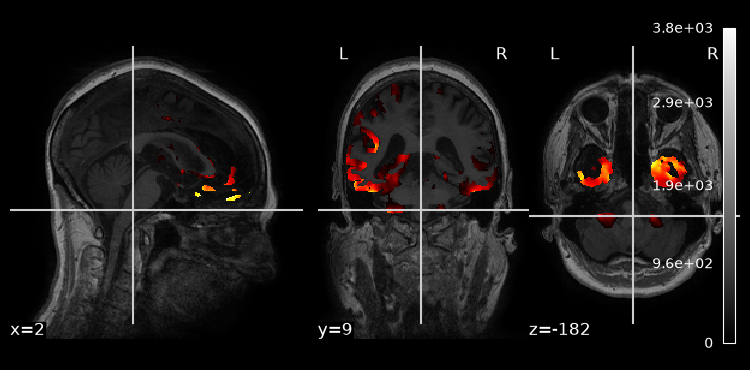

In [22]:

from nilearn import plotting


# 2. fond anatomique
disp = plotting.plot_anat(t1, )#display_mode="mosaic", cut_coords=1)
                        #   cut_coords=(10, 10, 0))  # remplacer par le centre de lesions ou le centre ATL

# 3. E-field en overlay continu
disp.add_overlay(efield, cmap="hot", threshold=0.1)

# 4. masque en contour par-dessus
# disp.add_contours(roi, levels=[0.5], colors="cyan")


# disp.savefig("overlay_sub-01.png", dpi=200)
# disp.close()

In [8]:
from nilearn import plotting

view = plotting.view_img(efield, bg_img=t1, threshold=0.1, cmap="hot")
view  # inline dans un notebook Jupyter
# ou
view.open_in_browser()  # depuis un script

/home/hippolyted/.pyenv/versions/nilearn/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
Gtk-Message: 11:31:25.791: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


In [9]:
from nilearn import plotting

# Masque binaire ROI superposé à la T1
display = plotting.plot_roi(
    roi_img=roi,      # le masque (catégorielle)
    bg_img=t1,            # le fond anatomique
    title="ROI M1 sur T1",
    cmap="autumn",                  # couleur du masque
    alpha=0.6,                      # transparence du masque
    display_mode="ortho",
    cut_coords=(-40, -20, 55),
)
display.savefig("roi_overlay.png", dpi=200)
display.close()

/home/hippolyted/.pyenv/versions/nilearn/lib/python3.12/site-packages/numpy/ma/core.py:2895: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


## Ipyniivue

In [ ]:
from ipyniivue import NiiVue

nv = NiiVue(
    height=600,
    is_colorbar=True,
    is_orient_cube=True,          # petit cube d'orientation
    back_color=(0.1, 0.1, 0.1, 1.0),
)

# 1. T1 = fond gris
nv.add_volume({
    "path": t1_path,
    "name": "T1",
    "colormap": "gray",
    "opacity": 1.0,
})

# 2. E-field = overlay continu "hot", seuillé via cal_min, semi-transparent
nv.add_volume({
    "path": efield_path,
    "name": "E-field",
    "colormap": "hot",
    "cal_min": 0.1,               # <-- équivalent de threshold=0.1
    "cal_max": 1.0,               # borne haute de la colormap
    "opacity": 0.7,
})

# 3. ROI = overlay coloré translucide (≈ ton contour, mais rempli)
nv.add_volume({
    "path": roi_path,
    "name": "ROI",
    "colormap": "red",
    "opacity": 0.4,
})

nv   # affiche le widget dans le notebook

In [2]:
from ipyniivue import NiiVue, SliceType

nv = NiiVue(height=600, back_color=(0.1, 0.1, 0.1, 1.0))

nv.load_volumes([
    # T1 = fond gris
    {"path": t1_path, "colormap": "gray", "opacity": 1.0},
    # E-field (magnitude) = overlay hot, seuillé via cal_min
    {"path": efield_path, "colormap": "hot",
     "cal_min": 0.1, "cal_max": 1.0, "opacity": 0.7},
    # mask = overlay coloré translucide
    {"path": roi_path, "colormap": "red", "opacity": 0.4},
])

# nv.set_slice_type(SliceType.RENDER)
nv.set_slice_type(SliceType.AXIAL)   # rendu 3D volumique pur
nv.set_render_azimuth_elevation(120, 15) 
    # TA CAMÉRA : azimut, élévation en degrés
# nv.set_volume_render_illumination(0.6)     # optionnel : ombrage matcap, plus de relief
nv   # <-- affiche le widget ; LAISSE cette cellule afficher avant de configurer le rendu ## ICI je ne voudrais plus l'afficher



In [28]:
# import time
# time.sleep(10)
nv.save_scene("efield_sub-02-test.png")           # TON SCREENSHOT


## NiftiView